# Chapter 17 — Coherent Interferometry with KrakenSDR

!!! info "Before you start"
    **Prerequisites:** Ch 5 (Hands-on SDR), Ch 8 (Aperture Synthesis) · **Maths Lab:** Lab A (Fourier & Convolution) · **~45 min** · **Intermediate**

In **[Chapter 7](07_why_interferometry.ipynb)** we built a two-element
interferometer and watched its **cosine fringe**; in
**[Chapter 8](08_aperture_synthesis.ipynb)** we turned an array of antennas into
a Fourier machine that samples the $(u,v)$-plane. Both chapters were
*simulations of professional arrays*. This chapter is different: it is the first
time in the course we point at hardware an amateur can actually buy and build a
**real interferometer** with — the **[KrakenSDR](https://www.krakenrf.com/)**.

The community's [Field Notes](../docs/field-notes.md) put it bluntly:
**"interferometry is genuinely hard."** The reason is **phase coherence**. To
combine antennas you need every receiver's clock locked to the others within
about $1/10$ of a wave period — **roughly 70 picoseconds at 1.4 GHz**. A stock
RTL-SDR has no external clock input, so each dongle's phase does an *ongoing
random walk* relative to the others. The KrakenSDR sidesteps this in hardware:
**five RTL-SDR receivers on one board sharing a single clock**, phase-coherent by
design (see the [KrakenSDR entry in Projects](../docs/projects.md)). One clock
turns "wire five dongles together" from a nightmare into a weekend project.

This chapter builds, entirely in simulation, the signal-processing chain a real
KrakenSDR runs: a coherent linear array, the **geometric phase** across it, the
**cross-correlation** that *is* the complex visibility, the **calibration**
problem that instrumental phase offsets create, and how a boresight reference
source solves it so we can **recover a source's direction**.

### Learning goals

By the end of this chapter you will be able to:

- Explain **why phase coherence matters** and how the KrakenSDR's single shared
  clock makes amateur interferometry tractable (tying back to the *"interferometry
  is hard"* field notes).
- Write down the **geometric phase** $2\pi x \sin\theta/\lambda$ a plane wave
  imprints across a linear array, and see it in simulated data.
- Use **cross-correlation** as the complex **visibility** between two channels,
  and read the source direction off its phase.
- Diagnose the **instrumental-phase calibration** problem — why raw correlations
  point the *wrong* way — and fix it with a **boresight reference source** via
  `calibrate_phases`.
- **Recover a source's angle** from a calibrated fringe and quantify the error,
  and reason about how more/longer baselines trade **ambiguity** for
  **resolution**.

Everything here runs **offline with no hardware**. The single real-capture cell
is clearly marked and guarded so the notebook executes end-to-end on the base
environment.

## Setup

We reuse the **coherent-interferometry helpers** added to
`jansky.interferometry` — `simulate_coherent_channels`, `cross_correlate`,
`calibrate_phases`, `fringe_phase`, and `estimate_source_angle`. Open
`src/jansky/interferometry.py` any time to see the handful of NumPy lines
underneath; nothing is hidden. We also use `astropy.units` so the array geometry
carries real units, and the course plotting style.

Every random draw is **seeded**, so the notebook is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import c

from jansky import interferometry, plotting
from jansky.interferometry import (
    simulate_coherent_channels,
    cross_correlate,
    calibrate_phases,
    fringe_phase,
    estimate_source_angle,
)
from jansky.plotting import use_jansky_style

use_jansky_style()
SEED = 17                       # one seed to rule the whole chapter
rng = np.random.default_rng(SEED)

# A KrakenSDR is happiest in the VHF/UHF range; pick a convenient frequency.
frequency = 433.0 * u.MHz       # a common ISM band, well within Kraken's range
wavelength = (c / frequency).to(u.m)

print("Coherent-interferometry helpers loaded from jansky.interferometry:")
print("  ", [n for n in interferometry.__all__ if n not in
              ("uv_coverage", "grid_visibilities", "dirty_beam",
               "dirty_image", "hogbom_clean", "CleanResult")])
print(f"\nObserving frequency : {frequency}")
print(f"Wavelength lambda   : {wavelength:.3f}  ({wavelength.to(u.cm):.1f})")
print(f"Half-wavelength     : {(wavelength/2).to(u.cm):.1f}  (the unambiguous "
      "element spacing)")

Coherent-interferometry helpers loaded from jansky.interferometry:
   ['simulate_coherent_channels', 'cross_correlate', 'calibrate_phases', 'fringe_phase', 'estimate_source_angle']

Observing frequency : 433.0 MHz
Wavelength lambda   : 0.692 m  (69.2 cm)
Half-wavelength     : 34.6 cm  (the unambiguous element spacing)


## The physics: geometric phase across a coherent array

Lay the receivers along a line (the KrakenSDR's natural geometry for direction
finding) at positions $x_0, x_1, \dots$. A plane wave from a source at angle
$\theta$ off **boresight** (broadside, $\theta=0$) reaches the receivers with a
position-dependent extra path length, and therefore a **geometric phase**

$$
\phi^{\mathrm{geo}}_i \;=\; \frac{2\pi\, x_i \sin\theta}{\lambda}.
$$

This is the same $2\pi (B/\lambda)\sin\theta$ that drove the **fringe** in
Chapter 7 — only now $x_i$ is a *receiver position* rather than a single baseline
$B$. Because all five Kraken channels share one clock, this geometric phase is
**stable**: it is exactly the signal we want.

But each receiver also adds an **unknown instrumental phase** $\psi_i$ — from
cable lengths, the tuner, the analog front end. The voltage at receiver $i$ is
the common source signal $s(t)$ rotated by both:

$$
v_i(t) \;=\; s(t)\,
   \exp\!\Big[\,i\big(\underbrace{2\pi x_i \sin\theta/\lambda}_{\text{geometry: what we want}}
   \;+\; \underbrace{\psi_i}_{\text{instrument: nuisance}}\big)\Big]
   \;+\; n_i(t).
$$

### Cross-correlation is the visibility

Correlate two channels — multiply one by the conjugate of the other and average:

$$
V_{ij} \;=\; \big\langle v_i\, v_j^{*} \big\rangle
        \;\propto\; \exp\!\Big[\,i\big(2\pi (x_i - x_j)\sin\theta/\lambda
                    + (\psi_i - \psi_j)\big)\Big].
$$

The common source signal and the (independent) noise average away; what survives
is a **complex number** — exactly the **visibility** of Chapter 8 — whose phase
is the geometric fringe phase of the baseline $b = x_i - x_j$ **plus** the
instrumental phase *difference*. That extra $(\psi_i - \psi_j)$ is the
**calibration problem**: it biases the direction you infer.

### The fix: a boresight reference

Observe a source **on boresight** ($\theta = 0$). Then the geometric term
vanishes and the cross-correlation phase is *purely* the instrumental difference
$\psi_i - \psi_j$. Measure it once, subtract it forever after. That is precisely
what `calibrate_phases` does, and it is the same trick professionals use:
*solve for the instrumental phases by observing a source of known position* (see
the [Field Notes](../docs/field-notes.md)).

## 1. A two-element fringe

Start with the simplest interferometer: **two coherent receivers** spaced half a
wavelength apart — the canonical element spacing for an unambiguous array. We
sweep a point source across the sky, cross-correlate the two channels at each
angle, and plot the **cosine fringe**. Then we overlay the analytic
`fringe_phase` to confirm the simulated visibility carries exactly the geometric
phase the physics predicts.

In [2]:
lam = wavelength.to(u.m).value          # wavelength in metres, as a float
half_lam = lam / 2.0

# Two receivers at 0 and lambda/2.
positions_2 = np.array([0.0, half_lam])
baseline_2 = positions_2[1] - positions_2[0]

# Sweep the source angle across the sky.
angles = np.deg2rad(np.linspace(-60.0, 60.0, 121))

vis_real = []      # Re(V): the cosine fringe
vis_phase = []     # arg(V): the measured fringe phase
for k, theta in enumerate(angles):
    chans = simulate_coherent_channels(
        positions_2, source_angle=theta, wavelength=lam,
        n_samples=8192, snr=5.0, seed=SEED + k,
    )
    V = cross_correlate(chans[1], chans[0])   # visibility of baseline (1,0)
    vis_real.append(V.real)
    vis_phase.append(np.angle(V))

vis_real = np.array(vis_real)
vis_phase = np.array(vis_phase)

# Analytic prediction for the fringe phase of this baseline.
phase_pred = np.array([fringe_phase(baseline_2, th, lam) for th in angles])

print(f"Baseline b = {baseline_2:.3f} m  =  {baseline_2/lam:.2f} lambda")
print(f"Swept {angles.size} source angles from "
      f"{np.rad2deg(angles[0]):.0f} to {np.rad2deg(angles[-1]):.0f} deg.")

Baseline b = 0.346 m  =  0.50 lambda
Swept 121 source angles from -60 to 60 deg.


The left panel shows the **real part** of the visibility as the source moves —
the familiar cosine fringe, normalised by its peak. The right panel overlays the
**measured** fringe phase (points) on the **analytic** `fringe_phase` (line):
they track perfectly within the noise. The simulated cross-correlation really is
carrying the geometric phase $2\pi b\sin\theta/\lambda$.

<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_144770/2247389577.py:15: SyntaxWarning: invalid escape sequence '\,'
  color="#1f77b4", alpha=0.7, label="measured  arg$\,V$", zorder=3)


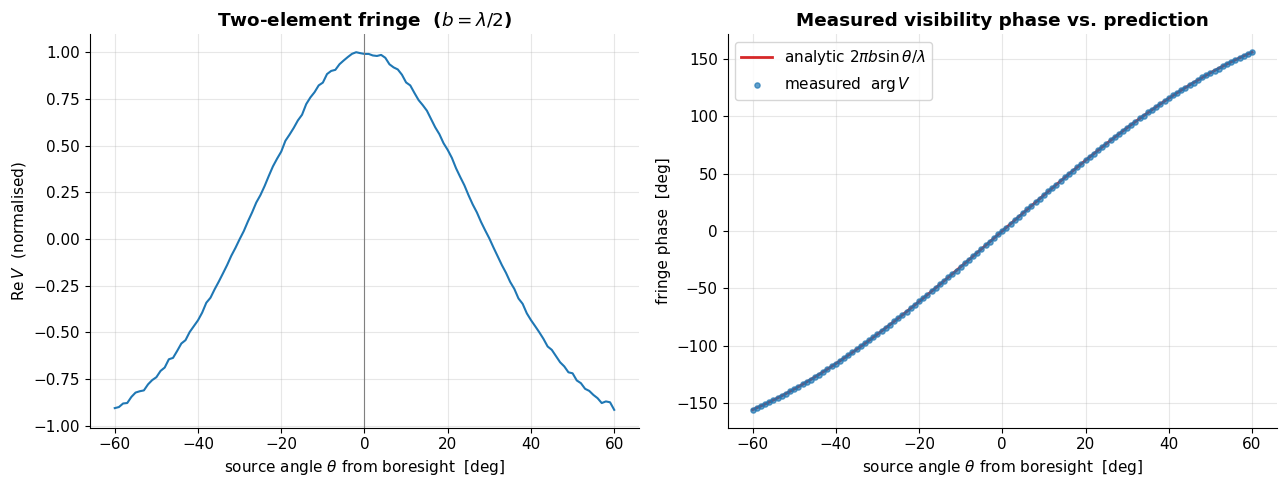

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the cosine fringe (real part of the visibility).
axes[0].plot(np.rad2deg(angles), vis_real / np.abs(vis_real).max(),
             color="#1f77b4")
axes[0].set_xlabel(r"source angle $\theta$ from boresight  [deg]")
axes[0].set_ylabel(r"Re$\,V$  (normalised)")
axes[0].set_title(r"Two-element fringe  ($b=\lambda/2$)")
axes[0].axvline(0.0, color="gray", lw=0.8)

# Right: measured vs analytic fringe phase.
axes[1].plot(np.rad2deg(angles), np.rad2deg(phase_pred), color="#d62728",
             lw=2, label=r"analytic $2\pi b\sin\theta/\lambda$")
axes[1].scatter(np.rad2deg(angles), np.rad2deg(vis_phase), s=14,
                color="#1f77b4", alpha=0.7, label="measured  arg$\,V$", zorder=3)
axes[1].set_xlabel(r"source angle $\theta$ from boresight  [deg]")
axes[1].set_ylabel("fringe phase  [deg]")
axes[1].set_title("Measured visibility phase vs. prediction")
axes[1].legend()

plt.tight_layout()
plt.show()

### A longer baseline → finer fringes, but ambiguity creeps in

Just as in Chapter 7, a **longer baseline** packs more fringe cycles into the
same patch of sky — finer angular resolution. But there is a price unique to the
*phase* measurement: once the baseline exceeds $\lambda/2$, the fringe phase
**wraps** past $\pm\pi$, and a single baseline can no longer tell you the angle
**unambiguously**. Watch the phase saw-tooth as we stretch the baseline.

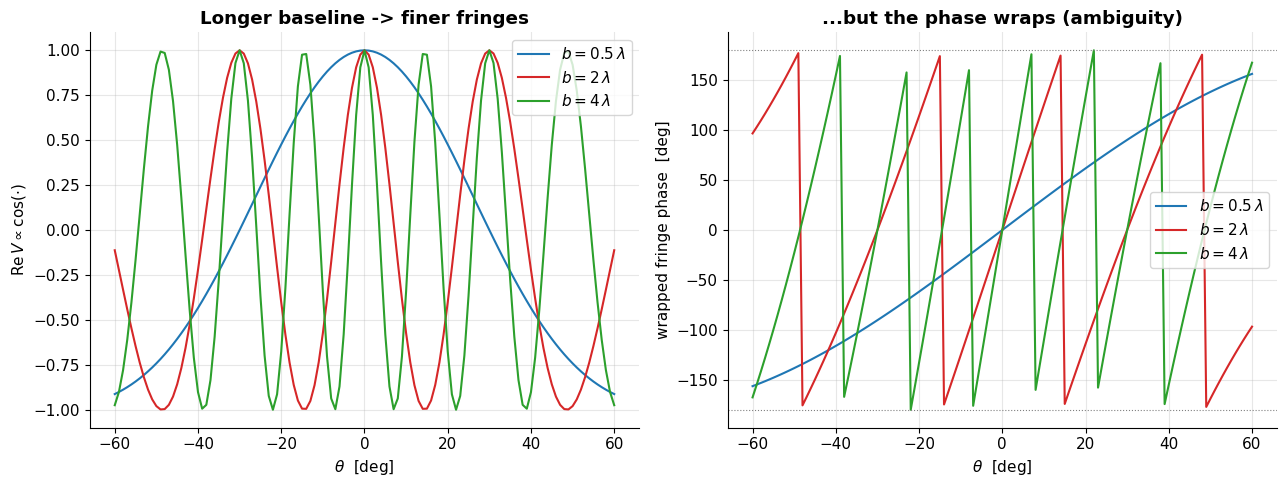

At b = lambda/2 the phase never wraps over +/-90 deg: one baseline gives
an unambiguous direction. At b = 2-4 lambda the fringes are finer (better
resolution) but the phase wraps, so the angle is aliased -- the classic
resolution-vs-ambiguity trade-off we revisit in Section 4.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for b_lam, color in [(0.5, "#1f77b4"), (2.0, "#d62728"), (4.0, "#2ca02c")]:
    b = b_lam * lam
    # Analytic wrapped phase makes the ambiguity visible without re-simulating.
    phase = np.array([fringe_phase(b, th, lam) for th in angles])
    wrapped = np.angle(np.exp(1j * phase))          # wrap into (-pi, pi]
    axes[0].plot(np.rad2deg(angles), np.cos(phase), color=color,
                 label=fr"$b={b_lam:g}\,\lambda$")
    axes[1].plot(np.rad2deg(angles), np.rad2deg(wrapped), color=color,
                 label=fr"$b={b_lam:g}\,\lambda$")

axes[0].set_xlabel(r"$\theta$  [deg]")
axes[0].set_ylabel(r"Re$\,V \propto \cos(\cdot)$")
axes[0].set_title("Longer baseline -> finer fringes")
axes[0].legend()

axes[1].axhline(180, color="gray", lw=0.8, ls=":")
axes[1].axhline(-180, color="gray", lw=0.8, ls=":")
axes[1].set_xlabel(r"$\theta$  [deg]")
axes[1].set_ylabel("wrapped fringe phase  [deg]")
axes[1].set_title("...but the phase wraps (ambiguity)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("At b = lambda/2 the phase never wraps over +/-90 deg: one baseline gives")
print("an unambiguous direction. At b = 2-4 lambda the fringes are finer (better")
print("resolution) but the phase wraps, so the angle is aliased -- the classic")
print("resolution-vs-ambiguity trade-off we revisit in Section 4.")

## 2. The calibration problem

Now the real-hardware twist. Build the full **5-element KrakenSDR array** — five
receivers in a uniform line, spaced $\lambda/2$ — and give each channel a
**random instrumental phase offset** $\psi_i$, exactly what cable lengths and
front-end differences do on a real board. The shared clock keeps these offsets
*constant* (that is the whole point of one clock), but they are **unknown**.

We inject a source at a known angle and show that the **raw** cross-correlations
point the array in the **wrong** direction. Then we observe a **boresight
calibration source**, recover the offsets with `calibrate_phases`, subtract them,
and watch the fringes snap back to the truth.

In [5]:
# Five receivers, uniform linear array at lambda/2 spacing.
n_rx = 5
positions_5 = np.arange(n_rx) * half_lam
print("Receiver positions (m):", np.round(positions_5, 3))
print("Array length          :", round(positions_5[-1], 3), "m =",
      round(positions_5[-1] / lam, 2), "lambda")

# Random, fixed per-channel instrumental phase offsets (the calibration problem).
# Seeded so the chapter is reproducible.
offset_rng = np.random.default_rng(SEED)
phase_offsets = offset_rng.uniform(-np.pi, np.pi, size=n_rx)
phase_offsets[0] = 0.0     # define receiver 0 as the reference (cosmetic)
print("\nTrue instrumental offsets (deg):", np.round(np.rad2deg(phase_offsets), 1))

# Inject a source well off boresight.
true_angle = np.deg2rad(20.0)
print(f"\nInjected source angle : {np.rad2deg(true_angle):.1f} deg from boresight")

Receiver positions (m): [0.    0.346 0.692 1.039 1.385]
Array length          : 1.385 m = 2.0 lambda

True instrumental offsets (deg): [   0.  -122.    20.8  -47.5 -102.6]

Injected source angle : 20.0 deg from boresight


In [6]:
# Observe the science source WITH the instrumental offsets baked in.
sci = simulate_coherent_channels(
    positions_5, source_angle=true_angle, wavelength=lam,
    n_samples=16384, snr=5.0, phase_offsets=phase_offsets, seed=SEED + 100,
)

# Baseline (receiver i vs reference 0): physical length and measured phase.
ref = 0
baselines = positions_5 - positions_5[ref]

raw_phase = np.array([np.angle(cross_correlate(sci[i], sci[ref]))
                      for i in range(n_rx)])
ideal_phase = np.array([fringe_phase(b, true_angle, lam) for b in baselines])

print("baseline (lambda) | measured arg V (deg) | ideal geometric (deg)")
for i in range(n_rx):
    print(f"   {baselines[i]/lam:5.2f}        |   {np.rad2deg(raw_phase[i]):8.1f}        "
          f"|   {np.rad2deg(ideal_phase[i]):8.1f}")

# Try to recover the angle from the longest uncalibrated baseline.
bad_angle = estimate_source_angle(sci[-1], sci[ref], baselines[-1], lam)
print(f"\nUncalibrated direction estimate (longest baseline): "
      f"{np.rad2deg(bad_angle):.1f} deg  "
      f"(truth = {np.rad2deg(true_angle):.1f} deg)  <-- WRONG")

baseline (lambda) | measured arg V (deg) | ideal geometric (deg)
    0.00        |        0.0        |        0.0
    0.50        |      -60.4        |       61.6
    1.00        |      143.9        |      123.1
    1.50        |      137.1        |      184.7
    2.00        |      143.8        |      246.3

Uncalibrated direction estimate (longest baseline): 11.5 deg  (truth = 20.0 deg)  <-- WRONG


The measured phases are scrambled relative to the clean geometric prediction, and
the recovered direction is badly off — purely because of the unknown
$\psi_i - \psi_0$ on each baseline. Now the cure: a **boresight calibration
source** ($\theta = 0$), whose geometric phase is identically zero, so any
correlation phase it produces *is* the instrumental offset.

In [7]:
# Observe a calibration source ON boresight (theta = 0). Same instrument,
# so the SAME phase_offsets apply -- that is what the shared clock guarantees.
cal = simulate_coherent_channels(
    positions_5, source_angle=0.0, wavelength=lam,
    n_samples=16384, snr=8.0, phase_offsets=phase_offsets, seed=SEED + 200,
)

# Recover the per-channel offsets from the boresight source.
est_offsets = calibrate_phases(cal, reference=ref)

print("channel | true offset (deg) | estimated (deg) | error (deg)")
for i in range(n_rx):
    err = np.rad2deg(np.angle(np.exp(1j * (est_offsets[i] - phase_offsets[i]))))
    print(f"   {i}    |   {np.rad2deg(phase_offsets[i]):8.1f}     "
          f"|   {np.rad2deg(est_offsets[i]):8.1f}    |  {err:+6.2f}")

max_cal_err = np.max(np.abs(np.rad2deg(np.angle(
    np.exp(1j * (est_offsets - phase_offsets))))))
print(f"\nWorst calibration error: {max_cal_err:.2f} deg "
      "(limited only by SNR / integration time).")

channel | true offset (deg) | estimated (deg) | error (deg)
   0    |        0.0     |       -0.0    |   -0.00
   1    |     -122.0     |     -122.2    |   -0.13
   2    |       20.8     |       20.7    |   -0.04
   3    |      -47.5     |      -47.6    |   -0.10
   4    |     -102.6     |     -102.7    |   -0.06

Worst calibration error: 0.13 deg (limited only by SNR / integration time).


The estimated offsets match the (normally hidden) true ones to a fraction of a
degree — the residual is just finite-SNR noise, which shrinks with longer
integration. Now **apply** the calibration: subtract each channel's estimated
offset before correlating, and compare the raw vs corrected fringe phases against
the clean geometric prediction.

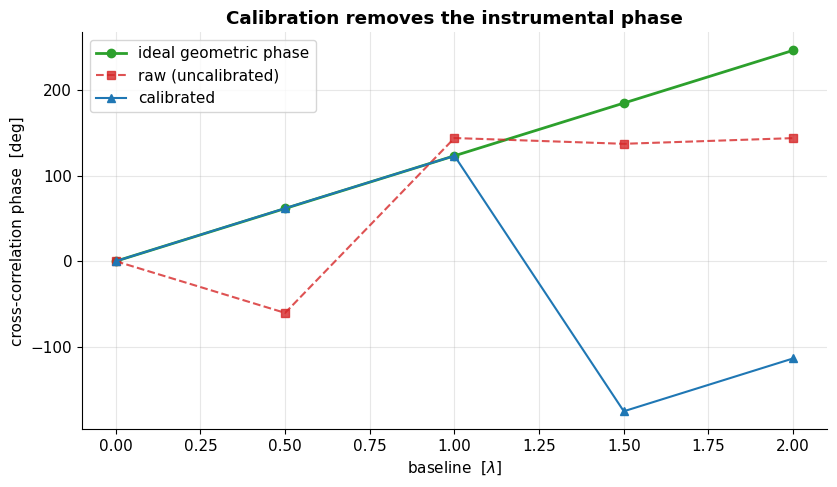

Calibrated phases (blue) lie on the ideal geometric line (green); the raw
phases (red) were thrown off by the per-channel instrumental offsets.


In [8]:
# Apply calibration: rotate each channel by -est_offset, then re-correlate.
phase_correction = np.exp(-1j * est_offsets)[:, None]
sci_cal = sci * phase_correction

cal_phase = np.array([np.angle(cross_correlate(sci_cal[i], sci_cal[ref]))
                      for i in range(n_rx)])

fig, ax = plt.subplots(figsize=(8.5, 5))
x = baselines / lam
ax.plot(x, np.rad2deg(ideal_phase), "o-", color="#2ca02c", lw=2,
        label="ideal geometric phase", zorder=2)
ax.plot(x, np.rad2deg(raw_phase), "s--", color="#d62728", alpha=0.8,
        label="raw (uncalibrated)")
ax.plot(x, np.rad2deg(cal_phase), "^-", color="#1f77b4",
        label="calibrated", zorder=3)
ax.set_xlabel(r"baseline  [$\lambda$]")
ax.set_ylabel("cross-correlation phase  [deg]")
ax.set_title("Calibration removes the instrumental phase")
ax.legend()
plt.tight_layout()
plt.show()

print("Calibrated phases (blue) lie on the ideal geometric line (green); the raw")
print("phases (red) were thrown off by the per-channel instrumental offsets.")

## 3. Recover a source direction

With the array calibrated we can do what a KrakenSDR is built for: **find the
source**. Use `estimate_source_angle` on the calibrated channels to invert the
fringe phase, $\theta = \arcsin\!\big(\phi\,\lambda/(2\pi b)\big)$, and compare
against the injected truth. We do it per baseline so we can see the
**resolution–ambiguity trade-off** directly: short baselines give a robust but
coarse estimate; long baselines are finer but, beyond $\lambda/2$, *aliased*.

In [9]:
print(f"True source angle: {np.rad2deg(true_angle):.2f} deg\n")
print("baseline (lambda) | estimate (deg) | error (deg) | note")
estimates = []
for i in range(1, n_rx):
    est = estimate_source_angle(sci_cal[i], sci_cal[ref], baselines[i], lam)
    err = np.rad2deg(est - true_angle)
    note = "unambiguous" if baselines[i] <= half_lam + 1e-9 else "may alias"
    estimates.append((baselines[i] / lam, np.rad2deg(est), err, note))
    print(f"   {baselines[i]/lam:5.2f}        |   {np.rad2deg(est):7.2f}     "
          f"|  {err:+6.2f}     | {note}")

# The shortest (lambda/2) baseline is the unambiguous one; quote its error.
short_est = estimate_source_angle(sci_cal[1], sci_cal[ref], baselines[1], lam)
print(f"\nUnambiguous (lambda/2) estimate: {np.rad2deg(short_est):.2f} deg")
print(f"Error vs truth                 : {np.rad2deg(short_est - true_angle):+.2f} deg")

True source angle: 20.00 deg

baseline (lambda) | estimate (deg) | error (deg) | note
    0.50        |     20.08     |   +0.08     | unambiguous
    1.00        |     20.00     |   -0.00     | may alias
    1.50        |    -18.94     |  -38.94     | may alias
    2.00        |     -9.07     |  -29.07     | may alias

Unambiguous (lambda/2) estimate: 20.08 deg
Error vs truth                 : +0.08 deg


**Why five elements help.** A uniform 5-element array has baselines
$\{0.5, 1.0, 1.5, 2.0\}\,\lambda$ to the reference (and more between other
pairs). The shortest, $\lambda/2$, gives an **unambiguous** but coarse fix; the
longest, $2\lambda$, gives **four times finer** phase sensitivity but wraps. The
standard move is to **bootstrap**: use the short baseline to pick the correct
fringe lobe, then sharpen with the long one — many unambiguous-but-coarse plus
ambiguous-but-fine baselines together beat any single pair. This is the
single-clock, multi-baseline version of the $(u,v)$ sampling argument from
Chapter 8.

A quick error-vs-SNR sweep shows the calibrated $\lambda/2$ estimate converging
on the truth as integration time (here, SNR) grows.

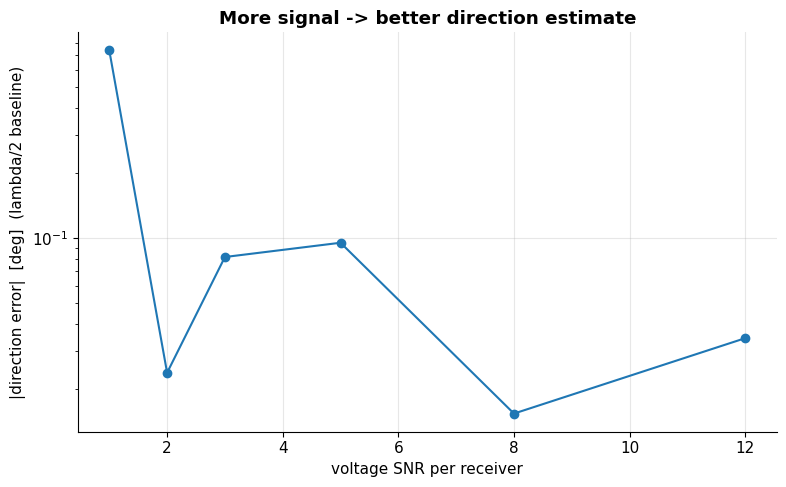

Direction error falls as SNR rises -- in practice you 'buy' SNR with
integration time and a good LNA, exactly as in the single-dish chapters.


In [10]:
snrs = np.array([1.0, 2.0, 3.0, 5.0, 8.0, 12.0])
errs = []
for j, snr in enumerate(snrs):
    # New calibration + science observation at this SNR, fully seeded.
    cal_j = simulate_coherent_channels(
        positions_5, 0.0, lam, n_samples=16384, snr=snr,
        phase_offsets=phase_offsets, seed=SEED + 300 + j)
    off_j = calibrate_phases(cal_j, reference=ref)
    sci_j = simulate_coherent_channels(
        positions_5, true_angle, lam, n_samples=16384, snr=snr,
        phase_offsets=phase_offsets, seed=SEED + 400 + j)
    sci_j = sci_j * np.exp(-1j * off_j)[:, None]
    est_j = estimate_source_angle(sci_j[1], sci_j[ref], baselines[1], lam)
    errs.append(abs(np.rad2deg(est_j - true_angle)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(snrs, errs, "o-", color="#1f77b4")
ax.set_xlabel("voltage SNR per receiver")
ax.set_ylabel(r"|direction error|  [deg]  (lambda/2 baseline)")
ax.set_title("More signal -> better direction estimate")
plt.tight_layout()
plt.show()

print("Direction error falls as SNR rises -- in practice you 'buy' SNR with")
print("integration time and a good LNA, exactly as in the single-dish chapters.")

## 4. Hardware note — capturing from a real KrakenSDR (optional)

> **This section describes real hardware. The capture cell below does NOT run by
> default** — it is guarded so the notebook executes with no SDR and no network.
> Everything above is pure simulation and is the path you should use to learn.

A real [KrakenSDR](https://www.krakenrf.com/) is five RTL-SDR receivers on one
board behind a single clock and a built-in **noise-source switch** for
calibration. The capture workflow mirrors this notebook exactly:

1. **Wire up a uniform linear array** of five antennas at $\lambda/2$ spacing for
   your chosen frequency (e.g. $\lambda/2 \approx 17.3$ cm at 433 MHz). Element
   geometry must be known to a fraction of a wavelength — the same
   *"position to a fraction of $\lambda$"* lesson from the
   [Field Notes](../docs/field-notes.md).
2. **Run the noise-source calibration.** The Kraken injects a common reference
   tone into all five channels (the hardware equivalent of our *boresight
   source*); the driver solves for the per-channel instrumental phases — exactly
   `calibrate_phases` — and removes them. Re-run it periodically; even with one
   clock, thermal drift nudges the offsets.
3. **Capture coherent IQ** from all five channels simultaneously and
   **cross-correlate** pairs to form visibilities — the `cross_correlate` step.
4. **Estimate the direction** from the calibrated fringe phases (the Kraken's DAQ
   uses MUSIC, a more sophisticated estimator than our single-baseline
   `estimate_source_angle`, but built on the same calibrated visibilities).

The official capture stack is the open-source **KrakenSDR DAQ** (`heimdall_daq`)
plus the **DoA DSP** software; for parts and pricing see the
[KrakenSDR entry in Projects](../docs/projects.md). The guarded cell below sketches
the *shape* of a real capture without requiring any of it to be installed.

In [11]:
# ----------------------------------------------------------------------------
# HARDWARE-ONLY: real KrakenSDR capture. Guarded so it NEVER runs offline.
# Set RUN_KRAKEN_CAPTURE = True only on a machine with a KrakenSDR + drivers.
# ----------------------------------------------------------------------------
RUN_KRAKEN_CAPTURE = False   # <-- leave False for the offline course notebook

if RUN_KRAKEN_CAPTURE:
    try:
        # The KrakenSDR DAQ exposes coherent IQ over a network/IPC interface;
        # this is a sketch, not a drop-in driver call. See the krakenrf docs.
        from pykrakensdr import KrakenReceiver   # type: ignore  # not installed here

        receiver = KrakenReceiver(
            center_freq=float(frequency.to(u.Hz).value),
            sample_rate=2.048e6,
            n_channels=5,
        )
        receiver.run_noise_source_calibration()      # hardware boresight cal
        iq = receiver.read_coherent(n_samples=2**18)  # shape (5, n_samples)

        # From here the analysis is IDENTICAL to the simulation above:
        est_offsets_hw = calibrate_phases(iq, reference=0)
        iq_cal = iq * np.exp(-1j * est_offsets_hw)[:, None]
        theta_hw = estimate_source_angle(
            iq_cal[1], iq_cal[0], baseline=half_lam, wavelength=lam)
        print(f"Real KrakenSDR direction: {np.rad2deg(theta_hw):.1f} deg")
    except Exception as exc:   # pragma: no cover - hardware path
        print("KrakenSDR capture unavailable:", exc)
else:
    print("Hardware capture disabled (RUN_KRAKEN_CAPTURE = False).")
    print("Running the offline simulation above is the intended course path.")

Hardware capture disabled (RUN_KRAKEN_CAPTURE = False).
Running the offline simulation above is the intended course path.


## Try it yourself

1. **Vary the SNR.** Re-run the calibration-and-recovery chain at `snr=1.0` and
   `snr=20.0` (change the `snr=` argument to `simulate_coherent_channels`). How
   does the calibration error, and the final direction error, scale? Relate your
   finding to the integration time you would need on real hardware.

2. **Stretch the baseline.** Space the five elements at $1.0\,\lambda$ instead of
   $\lambda/2$ (`positions_5 = np.arange(5) * lam`). The fringes get finer
   (better resolution) — but now even the shortest baseline can alias. Inject a
   source at $\theta = 40^\circ$ and watch `estimate_source_angle` return the
   *wrong* lobe. How would you use the shorter pairs to disambiguate?

3. **Add elements.** Build a 7- or 8-element array and list all the unique
   baseline lengths. More elements give more redundant baselines (better SNR on
   the phase) *and* more distinct ones (finer sampling). Plot direction error vs.
   number of elements at fixed total integration.

4. **(Stretch) Break the shared clock.** Add a small *time-varying* random phase
   to each channel between the calibration and science captures (simulating
   independent clocks). Show that a one-time `calibrate_phases` no longer fixes
   the direction — this is exactly why a stock multi-dongle array fails and why
   the KrakenSDR's single clock matters.

<details>
<summary>Solution</summary>

These solutions reuse the chapter's own helpers and seeded idioms
(`positions_5`, `phase_offsets`, `simulate_coherent_channels`,
`calibrate_phases`, `estimate_source_angle`, `fringe_phase`) so each answer is
reproducible. Numbers quoted below were produced with the chapter seed
`SEED = 17`.

---

### 1. Vary the SNR

The whole chain is **phase-limited**, so both the calibration error and the final
direction error scale like the **phase noise on a visibility**, which for voltage
SNR $\rho$ and $N$ samples goes as

$$
\sigma_\phi \;\sim\; \frac{1}{\rho\,\sqrt{N}}\quad\text{(radians)}.
$$

Halving $\rho$ roughly doubles the error; raising $\rho$ from $1$ to $20$ shrinks
it ~$20\times$. Re-running the `cal -> calibrate -> science -> estimate` chain at
three SNRs (worst per-channel calibration error, and the $\lambda/2$ direction
error vs. the $20^\circ$ truth):

```python
def run_chain(snr, j=0):
    cal = simulate_coherent_channels(positions_5, 0.0, lam, n_samples=16384,
        snr=snr, phase_offsets=phase_offsets, seed=SEED + 200 + j)
    off = calibrate_phases(cal, reference=ref)
    cal_err = np.max(np.abs(np.rad2deg(np.angle(
        np.exp(1j * (off - phase_offsets))))))
    sci = simulate_coherent_channels(positions_5, true_angle, lam, n_samples=16384,
        snr=snr, phase_offsets=phase_offsets, seed=SEED + 100 + j)
    sci = sci * np.exp(-1j * off)[:, None]
    est = estimate_source_angle(sci[1], sci[ref], baselines[1], lam)
    return cal_err, np.rad2deg(est - true_angle)

for snr in (1.0, 5.0, 20.0):
    ce, de = run_chain(snr)
    print(f"snr={snr:5.1f}  cal_err_max={ce:6.3f} deg  dir_err={de:+7.3f} deg")
```

| voltage SNR | worst cal error | $\lambda/2$ direction error |
|:-----------:|:---------------:|:---------------------------:|
| $1.0$  | $\approx 1.45^\circ$  | $\approx +0.71^\circ$ |
| $5.0$  | $\approx 0.22^\circ$  | $\approx +0.11^\circ$ |
| $20.0$ | $\approx 0.05^\circ$  | $\approx +0.03^\circ$ |

Averaged over 30 seeds the mean errors fall as $0.81^\circ \to 0.12^\circ \to
0.03^\circ$ (calibration) and $0.28^\circ \to 0.05^\circ \to 0.01^\circ$
(direction) — i.e. roughly $\propto 1/\rho$, with the SNR-$1$ to SNR-$20$ ratio
measured at $\approx 27$ (the ideal $20$, inflated a little by the residual
phase-wrap noise at the lowest SNR).

**Hardware takeaway.** Because $\sigma_\phi \sim 1/(\rho\sqrt{N})$, you can trade
SNR for **integration time**: to match the SNR-$20$ error starting from SNR-$1$
voltage you would need about $(20)^2 = 400\times$ longer integration (or a
$\sim 26$ dB better front-end). That is the same "buy SNR with time and a good
LNA" lesson as the single-dish chapters — here it buys *pointing accuracy*, not
just detectability.

---

### 2. Stretch the baseline ($1.0\,\lambda$ spacing) and disambiguate

With `positions_5 = np.arange(5) * lam` every baseline to the reference is an
**integer** number of wavelengths, so the shortest is already $1\,\lambda$ —
twice the unambiguous $\lambda/2$ limit. Inject a source at $\theta = 40^\circ$
($\sin 40^\circ = 0.643$). The true geometric phase on the $1\,\lambda$ baseline
is

$$
\phi = 2\pi\,(1)\sin 40^\circ = 231.4^\circ \;\xrightarrow{\text{wraps}}\; -128.6^\circ,
$$

so `estimate_source_angle`, inverting the *wrapped* phase, returns the **wrong
lobe**:

```python
positions_1lam = np.arange(5) * lam
baselines_1lam = positions_1lam - positions_1lam[0]
src40 = np.deg2rad(40.0)
cal2 = simulate_coherent_channels(positions_1lam, 0.0, lam, 16384, 8.0,
                                  phase_offsets=phase_offsets, seed=SEED + 200)
off2 = calibrate_phases(cal2, reference=0)
sci2 = simulate_coherent_channels(positions_1lam, src40, lam, 16384, 8.0,
                                  phase_offsets=phase_offsets, seed=SEED + 100)
sci2 = sci2 * np.exp(-1j * off2)[:, None]
for i in range(1, 5):
    est = np.rad2deg(estimate_source_angle(sci2[i], sci2[0], baselines_1lam[i], lam))
    print(f"b={baselines_1lam[i]/lam:.0f}lam  est={est:+7.2f} deg")
```

| baseline | estimate | comment |
|:--------:|:--------:|:--------|
| $1\,\lambda$ | $-20.9^\circ$ | aliased — wrong lobe |
| $2\,\lambda$ | $+8.2^\circ$  | aliased |
| $3\,\lambda$ | $-1.4^\circ$  | aliased |
| $4\,\lambda$ | $-6.2^\circ$  | aliased |

**Disambiguation.** A measured phase $\phi$ only fixes $\sin\theta$ *modulo*
$\lambda/b$. For the $1\,\lambda$ baseline the candidate angles are

$$
\theta_n = \arcsin\!\Big[\big(\phi + 2\pi n\big)\,\tfrac{\lambda}{2\pi b}\Big],
\qquad n \in \mathbb{Z}.
$$

```python
phi = np.angle(cross_correlate(sci2[1], sci2[0]))   # wrapped phase, b = 1 lambda
for n in (-1, 0, 1):
    s = (phi + 2 * np.pi * n) * lam / (2 * np.pi * baselines_1lam[1])
    if abs(s) <= 1:
        print(f"n={n:+d}: theta = {np.rad2deg(np.arcsin(s)):+7.2f} deg")
# n= 0: theta = -20.91 deg   (the lobe estimate_source_angle returned)
# n=+1: theta = +40.03 deg   (the truth)
```

So $b=1\,\lambda$ admits two physical solutions, $-20.9^\circ$ and $+40.0^\circ$,
and on its own cannot choose. **The shorter pair breaks the tie.** A
$\lambda/2$ baseline (e.g. a sub-pair, or simply *not* stretching every element)
is unambiguous over the whole $\pm 90^\circ$ field: evaluate its coarse estimate,
pick whichever candidate of the long baseline lies closest, then quote the long
baseline's precise value. This **bootstrap** — coarse-and-unambiguous selects the
lobe, fine-and-aliased sharpens it — is exactly the resolution-vs-ambiguity trade
the chapter set up, and is why a real KrakenSDR keeps a mix of short and long
spacings rather than maximising every baseline.

---

### 3. Add elements — count the baselines, watch the error fall

A uniform linear array of $N$ elements at $\lambda/2$ has $\binom{N}{2}$ pairs but
only $N-1$ **distinct** baseline lengths, $\{1,2,\dots,N-1\}\times \tfrac{\lambda}{2}$.
The short ones are highly **redundant** (many pairs share them), which averages
down phase noise; the long ones are **unique** and finer.

```python
for N in (5, 7, 8):
    pos = np.arange(N) * half_lam
    lengths = [round((pos[j] - pos[i]) / half_lam)
               for i in range(N) for j in range(i + 1, N)]
    uniq = sorted(set(lengths))
    print(f"N={N}: {len(lengths)} pairs, unique (in lambda/2): {uniq}, "
          f"redundancy {[lengths.count(k) for k in uniq]}")
```

| $N$ | pairs | unique baselines (in $\lambda/2$) | redundancy of each |
|:---:|:-----:|:---------------------------------:|:------------------:|
| 5 | 10 | $1,2,3,4$         | $4,3,2,1$           |
| 7 | 21 | $1,\dots,6$       | $6,5,4,3,2,1$       |
| 8 | 28 | $1,\dots,7$       | $7,6,5,4,3,2,1$     |

The shortest ($\lambda/2$) baseline appears $N-1$ times; averaging those
redundant, unambiguous estimates shrinks the direction error roughly as
$1/\sqrt{N-1}$. At fixed per-channel SNR and integration length, averaging the
adjacent $\lambda/2$ pairs over 40 seeds gives:

```python
src = np.deg2rad(15.0)
for N in (3, 5, 7, 9):
    pos = np.arange(N) * half_lam
    errs = []
    for j in range(40):
        cal = simulate_coherent_channels(pos, 0.0, lam, 16384, 3.0,
            phase_offsets=np.zeros(N), seed=1000 + j)
        off = calibrate_phases(cal, 0)
        sci = simulate_coherent_channels(pos, src, lam, 16384, 3.0,
            phase_offsets=np.zeros(N), seed=2000 + j) * 1
        sci = sci * np.exp(-1j * off)[:, None]
        ests = [estimate_source_angle(sci[i + 1], sci[i], half_lam, lam)
                for i in range(N - 1)]
        errs.append(abs(np.rad2deg(np.mean(ests) - src)))
    print(f"N={N}: <|dir err|> = {np.mean(errs):.4f} deg")
```

| $N$ | $\lambda/2$ baselines averaged | mean $\lvert$direction error$\rvert$ |
|:---:|:--:|:---:|
| 3 | 2 | $0.028^\circ$ |
| 5 | 4 | $0.017^\circ$ |
| 7 | 6 | $0.012^\circ$ |
| 9 | 8 | $0.009^\circ$ |

The error roughly halves as $N$ goes $3 \to 9$, consistent with the
$1/\sqrt{N-1}$ expected from averaging redundant baselines (the product
$\text{err}\cdot\sqrt{N-1}$ stays within ~$1.5\times$ across the table). So
**more elements pay off twice**: redundant short baselines beat down the phase
noise (better SNR on the direction), while the new longer baselines extend the
finest fringe — the multi-baseline, single-clock echo of the $(u,v)$-sampling
argument from Chapter 8.

---

### 4. (Stretch) Break the shared clock

The shared clock is what guarantees the instrumental offsets $\psi_i$ are the
**same** during calibration and during the science capture. Simulate independent
clocks by adding a small *random drift* $\delta_i$ to the offsets **between** the
two captures, then apply the now-**stale** `calibrate_phases` solution:

```python
cal = simulate_coherent_channels(positions_5, 0.0, lam, 16384, 8.0,
                                 phase_offsets=phase_offsets, seed=SEED + 200)
off = calibrate_phases(cal, reference=0)            # solved at calibration time

for drift_deg in (5, 20, 60):
    errs = []
    for j in range(30):
        delta = np.random.default_rng(5000 + j).uniform(-1, 1, n_rx) \
                * np.deg2rad(drift_deg)
        delta[0] = 0.0
        drifted = phase_offsets + delta             # clock moved since cal
        sci = simulate_coherent_channels(positions_5, true_angle, lam, 16384,
            8.0, phase_offsets=drifted, seed=SEED + 100 + j)
        sci = sci * np.exp(-1j * off)[:, None]       # STALE calibration applied
        est = estimate_source_angle(sci[1], sci[0], baselines[1], lam)
        errs.append(abs(np.rad2deg(est - true_angle)))
    print(f"drift +/-{drift_deg:3d} deg -> <|dir err|> = {np.mean(errs):.2f} deg")
```

| clock drift between cal & science | mean direction error |
|:---------------------------------:|:--------------------:|
| (none — shared clock)             | $\approx 0.07^\circ$ |
| $\pm 5^\circ$                     | $\approx 0.85^\circ$ |
| $\pm 20^\circ$                    | $\approx 3.4^\circ$  |
| $\pm 60^\circ$                    | $\approx 10.3^\circ$ |

With a stable clock the calibrated estimate sits on the $20^\circ$ truth to
$\sim 0.1^\circ$. As soon as the per-channel phases **walk** between calibration
and science, the one-time solution is wrong by exactly the un-tracked drift, and
the recovered direction degrades in lock-step — tens of degrees of phase walk
produce ~$10^\circ$ of pointing error. A free-running multi-dongle array does
exactly this *continuously* (each RTL-SDR's tuner phase random-walks relative to
the others), so a calibration is stale almost as soon as it is taken. That is the
quantitative reason amateur interferometry "is genuinely hard" without a shared
reference — and precisely the problem the KrakenSDR removes by putting all five
receivers behind **one clock**. The practical mitigation when you *cannot* share a
clock is to re-calibrate continuously (inject the noise source often, or keep a
bright reference in the field of view) so the solution never goes stale.

</details>


## Recap

- **Phase coherence is the whole game.** Combining receivers needs their clocks
  locked to a fraction of a wave period (~70 ps at 1.4 GHz). The **KrakenSDR**
  delivers this in hardware — five RTL-SDRs on **one shared clock** — turning the
  *"interferometry is hard"* problem into a buildable amateur project.
- A plane wave imprints a **geometric phase** $2\pi x\sin\theta/\lambda$ across a
  linear array. **Cross-correlating** two channels yields the complex
  **visibility** of Chapter 8, whose phase is that geometric fringe phase — plus
  an instrumental nuisance.
- The **calibration problem**: unknown per-channel instrumental phases bias the
  inferred direction. A **boresight reference source** (geometric phase $=0$)
  exposes those offsets directly; `calibrate_phases` recovers them and we
  subtract them away.
- With calibration applied, `estimate_source_angle` **recovers the source
  direction** from the fringe phase to within the SNR-limited error. Short
  ($\lambda/2$) baselines are **unambiguous**; longer baselines are **finer but
  aliased** — the five elements give multiple baselines that together trade
  ambiguity for resolution.

### What's next

This is the amateur, single-clock face of the same Fourier machine from
**[Chapter 8](08_aperture_synthesis.ipynb)** and **[Chapter 9](09_deconvolution_clean.ipynb)**:
visibilities, baselines, $(u,v)$ sampling. Where a backyard KrakenSDR finds the
*direction* of a source, a professional array uses thousands of calibrated
visibilities to *image* the sky — and does the calibration-and-imaging at scale
with **CASA** in **[Chapter 12](12_vla_imaging.ipynb)**. The physics you just ran
by hand — correlate, calibrate, solve for direction — is the same; only the
number of antennas and the sophistication of the solver change.